In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler  # to scale a data and standard deviation
import scipy.stats as stats                        #used for Statistical analysis.
from sklearn.preprocessing import PolynomialFeatures,StandardScaler  # Non-linear relationships

In [2]:
df = pd.read_csv("/content/Student_Performance.csv")

In [3]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [6]:
df.shape

(10000, 6)

In [7]:
df.describe()  #show mean , std, min, count , max , 25 , 50 and 75 % quartile

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [8]:
df.columns   #column name

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [9]:
df.isnull()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
9995,False,False,False,False,False,False
9996,False,False,False,False,False,False
9997,False,False,False,False,False,False
9998,False,False,False,False,False,False


In [10]:
df.isnull().sum().sum()  #show missing value

np.int64(0)

In [11]:
df.duplicated().sum().sum() #show duplicated value

np.int64(127)

In [15]:
print(f"Number of nulls :{df.isnull().sum().sum()}")
print(f"Number of duplicates :{df.duplicated().sum().sum()}")
df = df.drop_duplicates()
print (f"Number of duplicate after dropping : {df.duplicated().sum()}")

Number of nulls :0
Number of duplicates :127
Number of duplicate after dropping : 0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# StandardScaler: Used to standardize numerical features
# LabelEncoder: Used to convert categorical text data into numerical values

le = LabelEncoder()

# Convert 'Extracurricular Activities' (Yes/No) into numeric values (0/1)
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

/tmp/ipykernel_33311/1499679890.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])


In [22]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


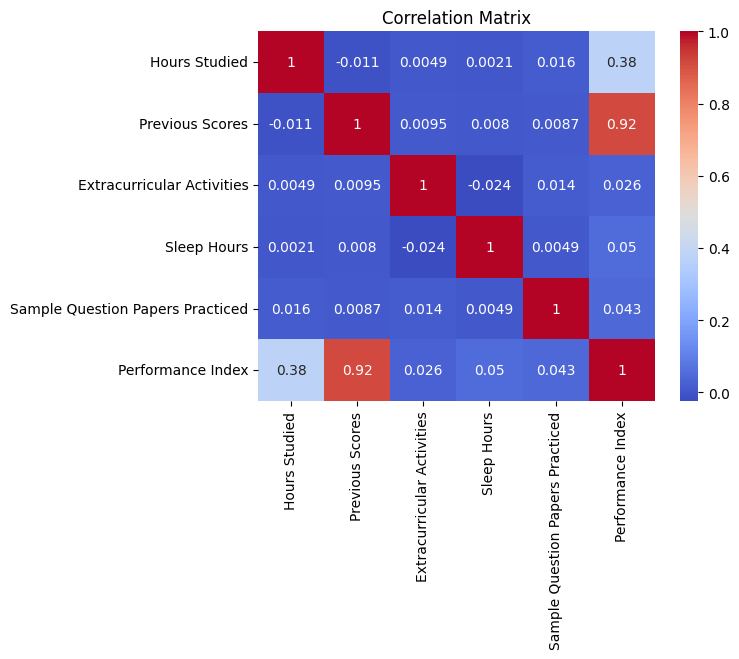

In [23]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Split data and normalization**

In [28]:
y = df['Performance Index']
X = df.drop('Performance Index', axis=1)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(8885, 5)
(988, 5)
(8885,)
(988,)


**Linear Regression Model**

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

feature = 'Previous Scores'
X_single_train = X_train[[feature]]
X_single_test = X_test[[feature]]

model = LinearRegression()
model.fit(X_single_train, y_train)

y_pred = model.predict(X_single_test)

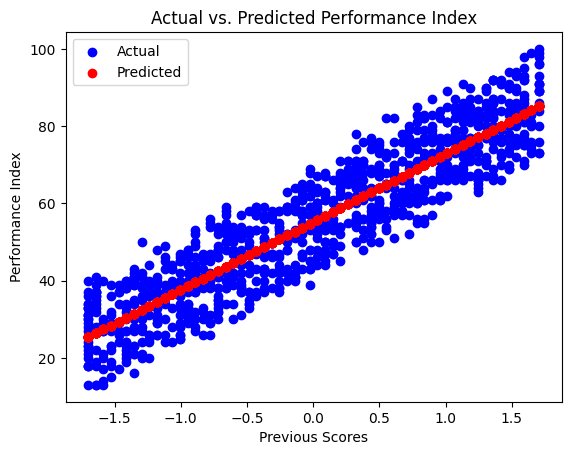

In [30]:
plt.scatter(X_single_test[feature], y_test, color='blue', label='Actual')
plt.scatter(X_single_test[feature], y_pred, color='red', label='Predicted')
plt.xlabel(feature)
plt.ylabel('Performance Index')
plt.title('Actual vs. Predicted Performance Index')
plt.legend()
plt.show()

In [32]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R-squared: {r2:.2f}')
print(f'Mean Squared Error: {mse:.2f}')

R-squared: 0.84
Mean Squared Error: 60.00


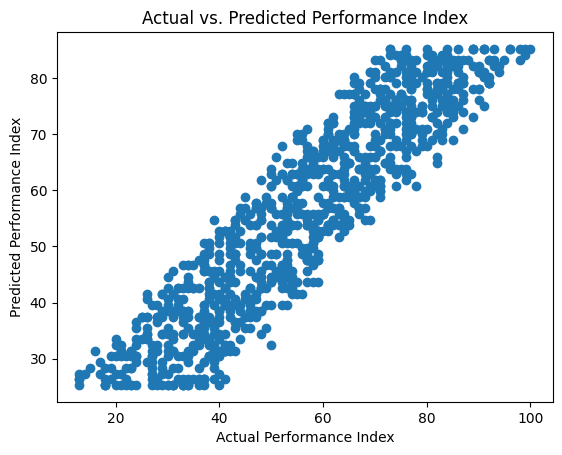

In [33]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs. Predicted Performance Index')
plt.show()

In [34]:
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.2f}')

R-squared: 0.84


In [35]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 60.00


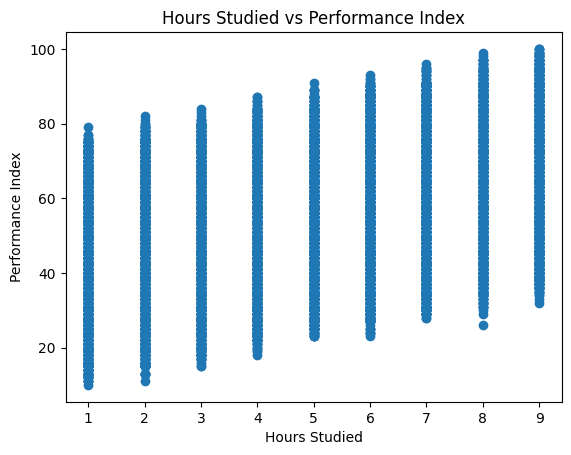

In [36]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours Studied'], df['Performance Index'])
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.title('Hours Studied vs Performance Index')
plt.show()

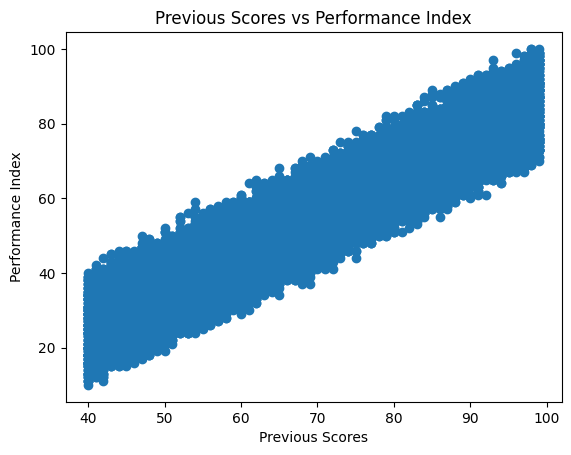

In [37]:
import matplotlib.pyplot as plt

plt.scatter(df['Previous Scores'], df['Performance Index'])
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.title('Previous Scores vs Performance Index')
plt.show()

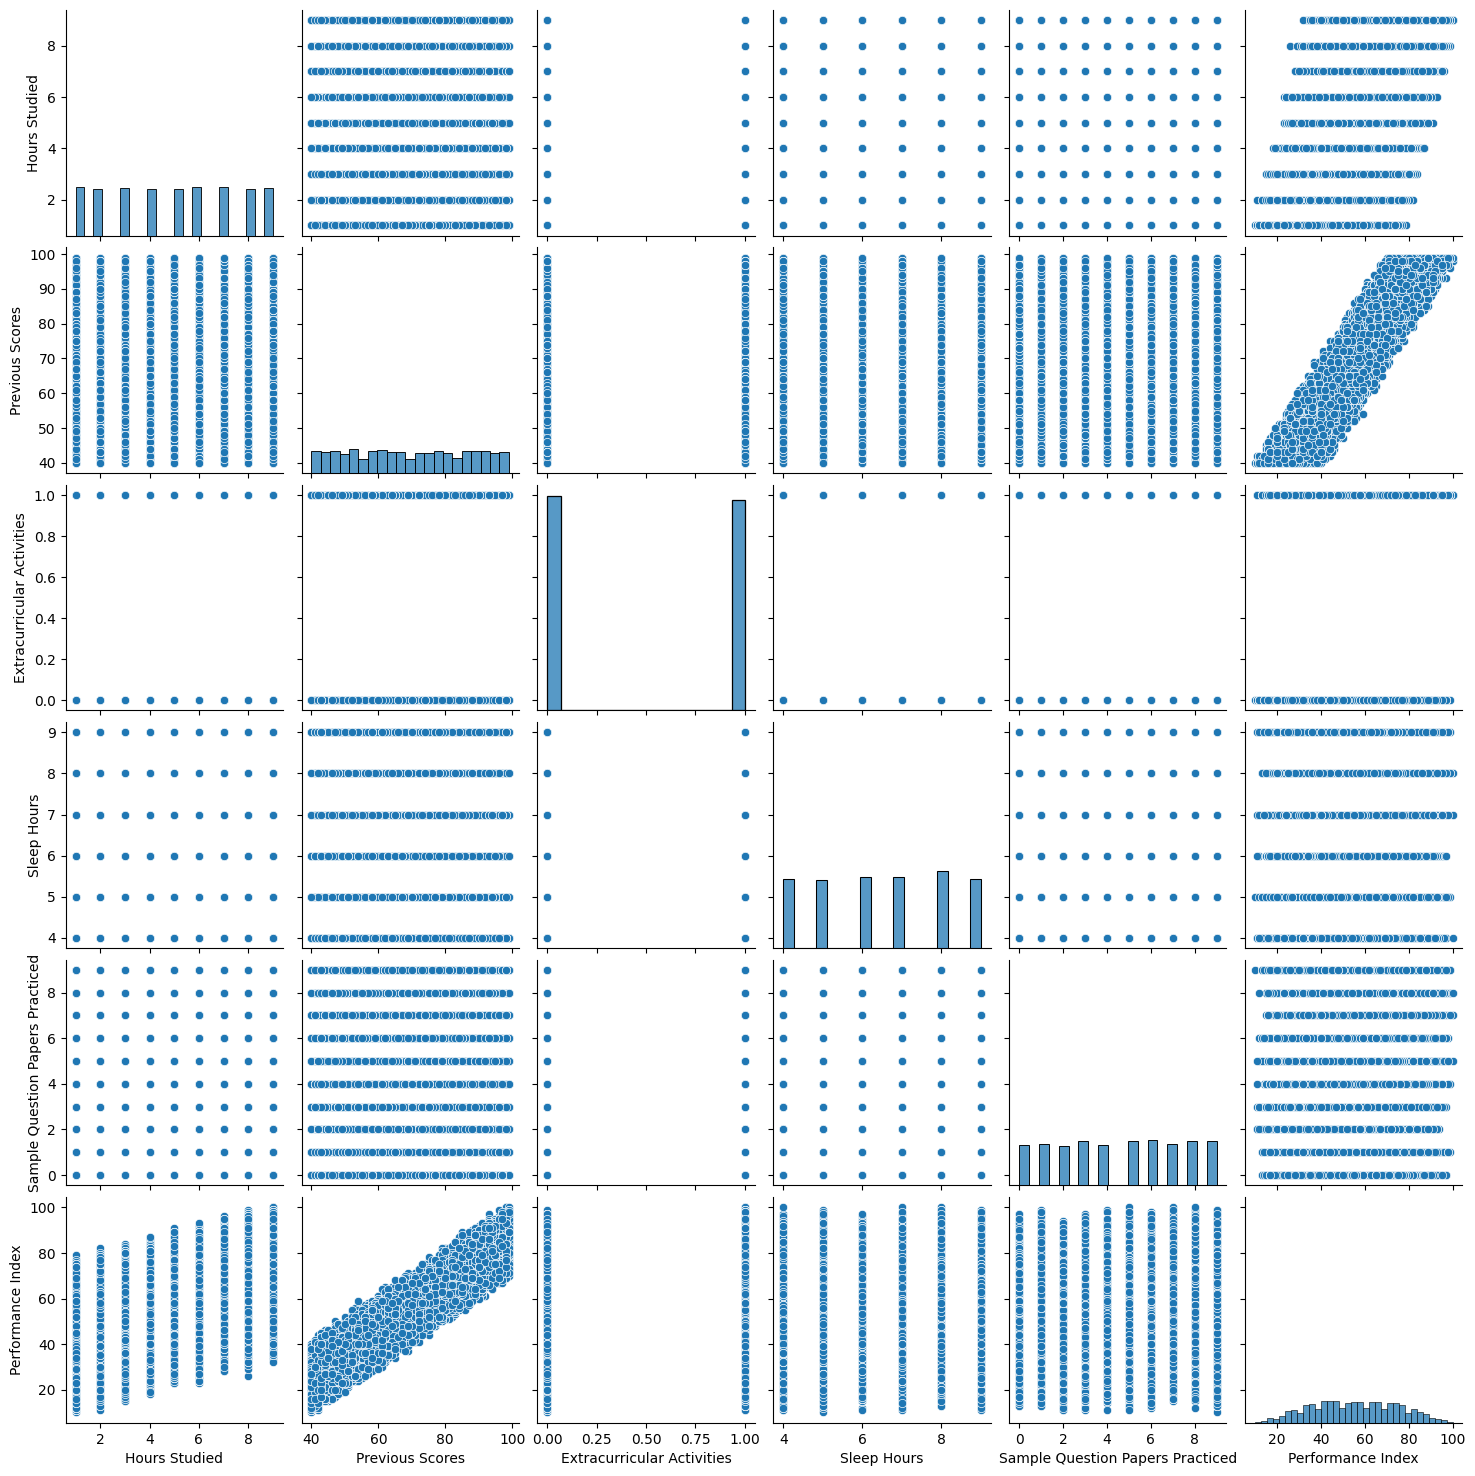

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

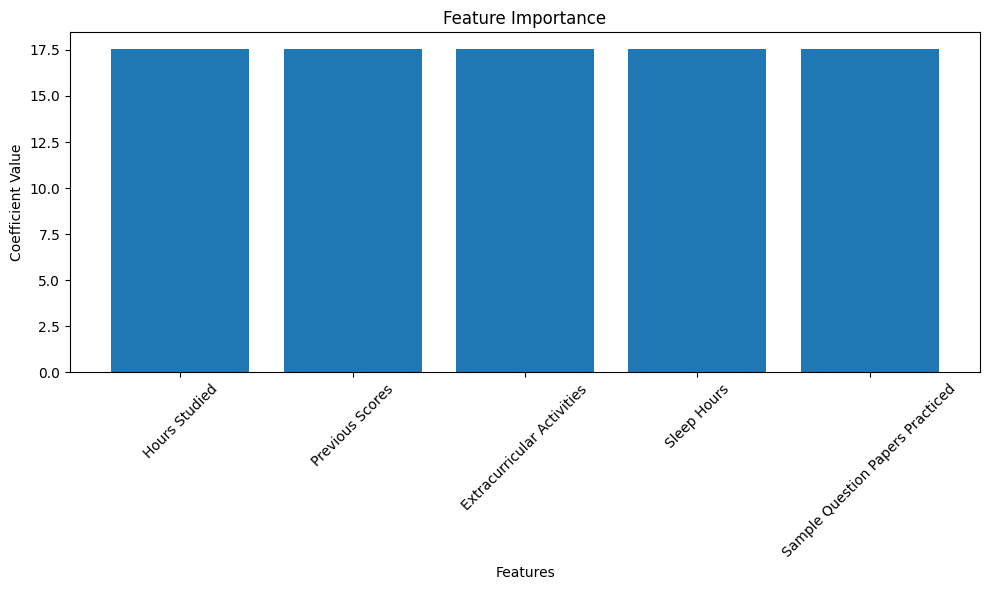

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

features = X_train.columns

# Convert coefficients to 1D array
coef = np.ravel(model.coef_)

plt.figure(figsize=(10, 6))
plt.bar(features, coef)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("Student_Performance.csv")

# Encode Yes/No column
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

# Features and Target
X = df[['Hours Studied',
        'Previous Scores',
        'Extracurricular Activities',
        'Sleep Hours',
        'Sample Question Papers Practiced']]

y = df['Performance Index']

# Train Model
model = LinearRegression()
model.fit(X, y)

# Grade Function
def get_grade(score):
    if score >= 85:
        return "A"
    elif score >= 80:
        return "A-"
    elif score >= 75:
        return "B+"
    elif score >= 70:
        return "B"
    elif score >= 65:
        return "B-"
    elif score >= 60:
        return "C+"
    elif score >= 50:
        return "C"
    else:
        return "F"

# GPA Function
def get_gpa(score):
    if score >= 85:
        return 4.0
    elif score >= 80:
        return 3.7
    elif score >= 75:
        return 3.3
    elif score >= 70:
        return 3.0
    elif score >= 65:
        return 2.7
    elif score >= 60:
        return 2.3
    elif score >= 50:
        return 2.0
    else:
        return 0.0

# User Input
name = input("Enter Student Name: ")
subject = input("Enter Subject: ")

hours = float(input("Hours Studied: "))
previous = float(input("Previous Score: "))
sleep = float(input("Sleep Hours: "))
papers = float(input("Sample Papers Practiced: "))

activity = input("Extracurricular Activities (Yes/No): ").strip().lower()

if activity == "yes":
    activity = 1
else:
    activity = 0

# Prediction Data
student_data = pd.DataFrame({
    'Hours Studied': [hours],
    'Previous Scores': [previous],
    'Extracurricular Activities': [activity],
    'Sleep Hours': [sleep],
    'Sample Question Papers Practiced': [papers]
})

# Predict
predicted_score = model.predict(student_data)[0]

grade = get_grade(predicted_score)
gpa = get_gpa(predicted_score)

# Output
print("\n========== STUDENT REPORT ==========")
print("Name:", name)
print("Subject:", subject)
print("Predicted Performance Index:", round(predicted_score, 2))
print("Predicted Grade:", grade)
print("Predicted GPA:", gpa)

if predicted_score < 50:
    print("Status: At Risk Student")
else:
    print("Status: Safe Student")

Enter Student Name: ali
Enter Subject: 1
Hours Studied: 3
Previous Score: 85
Sleep Hours: 4
Sample Papers Practiced: 2
Extracurricular Activities (Yes/No): No

========== STUDENT REPORT ==========
Name: ali
Subject: 1
Predicted Performance Index: 63.36
Predicted Grade: C+
Predicted GPA: 2.3
Status: Safe Student


In [52]:
import pickle
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Save model as Pickle
with open("student_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save model as Joblib
joblib.dump(model, "student_model.joblib")

# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

# Save correlation matrix as CSV
corr_matrix.to_csv("correlation_matrix.csv")

# Save heatmap image
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("correlation_heatmap.png")
plt.close()

print("✓ Model saved as student_model.pkl")
print("✓ Model saved as student_model.joblib")
print("✓ Correlation matrix saved as correlation_matrix.csv")
print("✓ Heatmap saved as correlation_heatmap.png")

✓ Model saved as student_model.pkl
✓ Model saved as student_model.joblib
✓ Correlation matrix saved as correlation_matrix.csv
✓ Heatmap saved as correlation_heatmap.png


In [53]:
import joblib

joblib.dump(model, "student_model.joblib")

['student_model.joblib']

In [56]:
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("student_model.joblib")